**EDA (Exploratory Data Analysis)**

In [1]:
from google.colab import drive
import os
import pandas as pd

drive.mount("/content/drive")
print(os.listdir("/content/drive/MyDrive/HealthData/SkinCancer"))
metadata = pd.read_csv("/content/drive/MyDrive/HealthData/SkinCancer/HAM10000_metadata.csv")

Mounted at /content/drive
['survey lung cancer.csv', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv', 'hmnist_8_8_L.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_RGB.csv', 'HAM10000_images_part_1', 'HAM10000_images_part_2']


In [2]:
metadata.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')

In [3]:
metadata_dx_classifications = {"akiec":"Actinic keratoses and intraepithelial carcinoma/Bowen's Disease",
               "bcc":"Basal cell carcinoma",
               "bkl":"Benign karatosis-like lesions (solar lentigines/seborrheic karatoses and lichen-planus like keratoses)",
               "df":"Dermatofibroma",
               "mel":"Melanoma",
               "nv": "Melanocytic nevi",
               "vasc":"Vascular lesions (angiomas, angiokeratomas, pyogenic granulomas and hemorrhage)"}

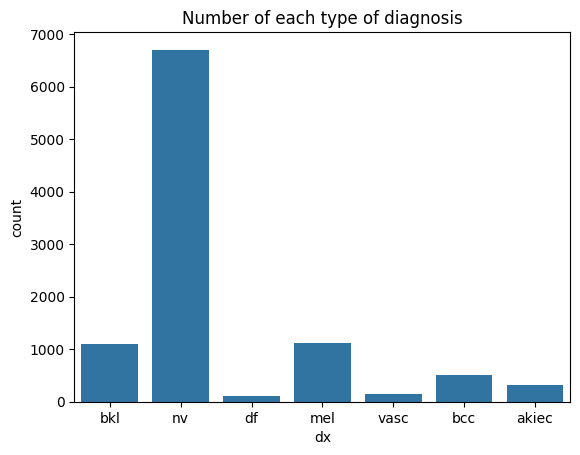

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# count plot on single categorical variable
sns.countplot(x ='dx', data = metadata)

# Show the plot
plt.title("Number of each type of diagnosis")

plt.show()

In [5]:
unique_lesions_list = list(set(metadata["lesion_id"]))
len(unique_lesions_list)

7470

In [6]:
len(metadata["lesion_id"])

10015

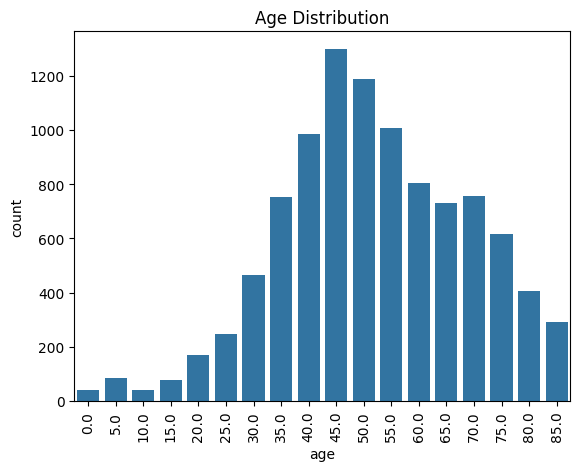

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# count plot on single categorical variable
sns.countplot(x = 'age', data = metadata)

# Show the plot
plt.xticks(rotation=90)
plt.title("Age Distribution")

plt.show()

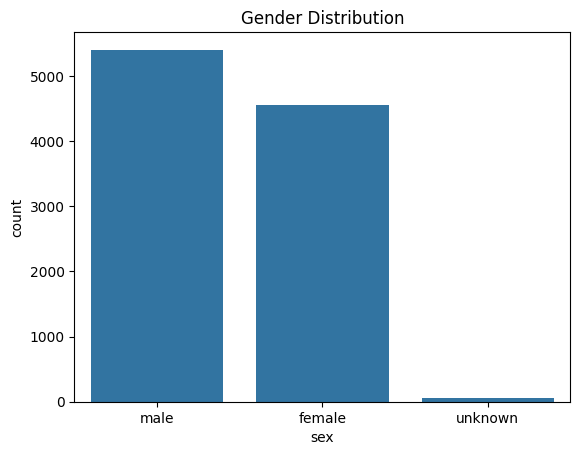

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# count plot on single categorical variable
sns.countplot(x ='sex', data = metadata)

# Show the plot
plt.title("Gender Distribution")

plt.show()

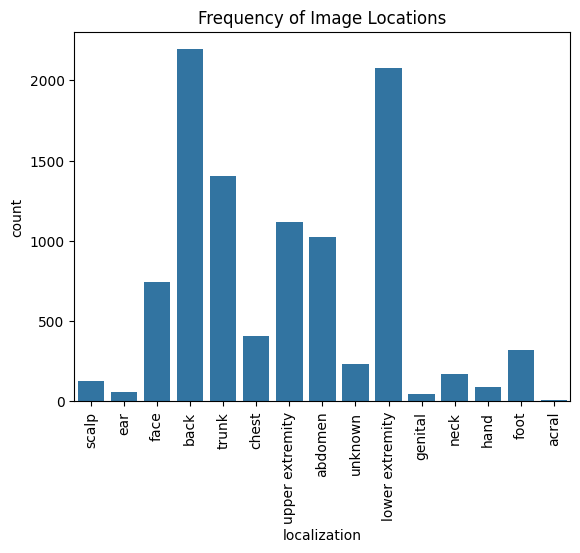

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# count plot on single categorical variable
sns.countplot(x ='localization', data = metadata)

# Show the plot
plt.xticks(rotation=90)
plt.title("Frequency of Image Locations")

plt.show()

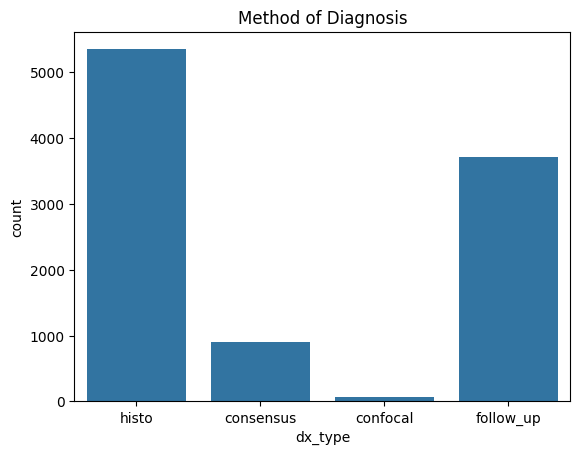

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# count plot on single categorical variable
sns.countplot(x ='dx_type', data = metadata)

# Show the plot
plt.title("Method of Diagnosis")

plt.show()

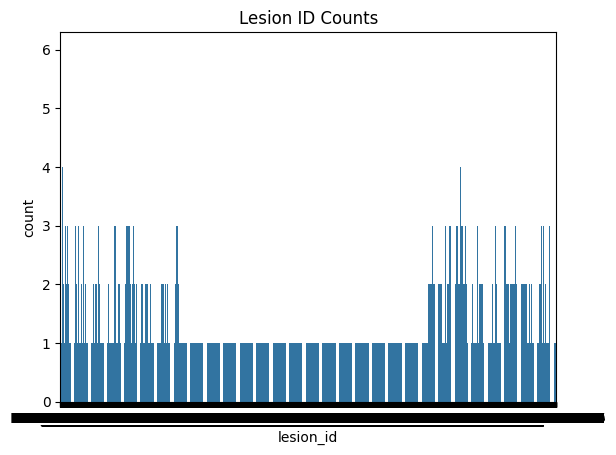

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# count plot on single categorical variable
sns.countplot(x ='lesion_id', data = metadata)

# Show the plot
plt.title("Lesion ID Counts")

plt.show()

In [12]:
#Unique list of lesions
# initialize dictionary variables
# loop through each lesion in the lesion list, metatdata["lesion_id"]
# check if lesion is in dictionary using dict.get(lesion_id)
# if None, dict[lesion_id] = 1
# else: dict[lesion_id] += 1

lesions_count = {}

for i in range(len(metadata["lesion_id"])):
  temp_lesion_id = metadata["lesion_id"][i]
  if lesions_count.get(temp_lesion_id) == None:
    lesions_count[temp_lesion_id] = 1
  else:
    lesions_count[temp_lesion_id] += 1

print(lesions_count)

{'HAM_0000118': 2, 'HAM_0002730': 2, 'HAM_0001466': 2, 'HAM_0002761': 2, 'HAM_0005132': 2, 'HAM_0001396': 1, 'HAM_0004234': 2, 'HAM_0001949': 2, 'HAM_0007207': 1, 'HAM_0001601': 2, 'HAM_0007571': 2, 'HAM_0006071': 1, 'HAM_0003301': 2, 'HAM_0004884': 2, 'HAM_0002521': 2, 'HAM_0006574': 2, 'HAM_0001480': 2, 'HAM_0005772': 2, 'HAM_0005612': 1, 'HAM_0005388': 1, 'HAM_0000351': 2, 'HAM_0003847': 4, 'HAM_0000164': 2, 'HAM_0007409': 3, 'HAM_0002299': 2, 'HAM_0007010': 2, 'HAM_0003670': 1, 'HAM_0007125': 2, 'HAM_0001221': 2, 'HAM_0001983': 1, 'HAM_0003569': 2, 'HAM_0000700': 1, 'HAM_0000728': 1, 'HAM_0003021': 4, 'HAM_0000959': 4, 'HAM_0001751': 1, 'HAM_0004569': 2, 'HAM_0004641': 2, 'HAM_0005801': 2, 'HAM_0004341': 2, 'HAM_0000907': 2, 'HAM_0001469': 2, 'HAM_0001728': 1, 'HAM_0001773': 2, 'HAM_0002127': 2, 'HAM_0002092': 2, 'HAM_0005075': 2, 'HAM_0002921': 1, 'HAM_0003410': 2, 'HAM_0004852': 2, 'HAM_0000746': 1, 'HAM_0001473': 1, 'HAM_0003007': 2, 'HAM_0002957': 2, 'HAM_0002985': 1, 'HAM_0003

{'bkl': 287, 'nv': 988, 'df': 34, 'mel': 384, 'vasc': 34, 'bcc': 152, 'akiec': 77}
  dx_type  dx_count
0     bkl       287
1      nv       988
2      df        34
3     mel       384
4    vasc        34
5     bcc       152
6   akiec        77


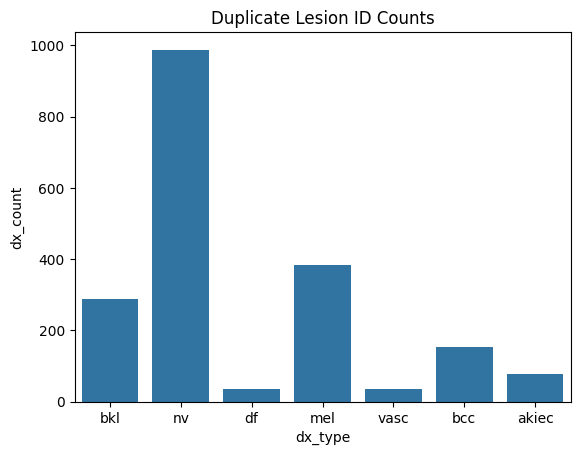

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
#Create a dictionary to associate different dx types with the number of duplicate lesions
dx_count = {"bkl":0, "nv":0, "df":0, "mel":0, "vasc":0, "bcc":0, "akiec":0}

#Create a list that has all of the lesions in the original data
list_of_lesions = list(metadata["lesion_id"])

lesions_count = {}

#Create a dictionary that associates each lesion-id with the number of times it appears in the dataset
for i in range(len(metadata["lesion_id"])):
  temp_lesion_id = metadata["lesion_id"][i]
  if lesions_count.get(temp_lesion_id) == None:
    lesions_count[temp_lesion_id] = 1
  else:
    lesions_count[temp_lesion_id] += 1

#Remove any lesions in the dictionary that have a count of only one (won't impact the plot at all) and update key list
lesions_count_keys = list(lesions_count.keys())

for lesion_key in lesions_count_keys:
  if lesions_count.get(lesion_key) == 1:
    del lesions_count[lesion_key]

lesions_count_keys = list(lesions_count.keys())

#Check each value in the lesions_count dictionary to see the dx associated with it, update the dx_count dictionary to reflect this

for lesion_key in lesions_count_keys:
  lesion_index = list_of_lesions.index(lesion_key)
  dx_diagnosis = list(metadata['dx'])[lesion_index]
  dx_count[dx_diagnosis] += 1

print(dx_count)

dx_count2 = {}
dx_count2["dx_type"] = list(dx_count.keys())
dx_count2["dx_count"] = list(dx_count.values())


#Convert dictionary to a dataframe and plot
dx_dataframe = pd.DataFrame(dx_count2)
print(dx_dataframe)

# count plot on single categorical variable
sns.barplot(x ='dx_type', y = 'dx_count', data = dx_dataframe)

# Show the plot
plt.title("Duplicate Lesion ID Counts")

plt.show()

In [14]:
len(lesions_count)

1956

**Loading Dataset**

In [15]:
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import SGD
from sklearn.model_selection import train_test_split
from tensorflow import keras
import keras
import numpy as np
import os
import cv2
import sys
sys.setrecursionlimit(10**7)
import sklearn

In [16]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import BatchNormalization

In [17]:
dataset_part_1 = "/content/drive/MyDrive/HealthData/SkinCancer/HAM10000_images_part_1/"
dataset_part_2 = "/content/drive/MyDrive/HealthData/SkinCancer/HAM10000_images_part_2/"
files_1 = os.listdir(dataset_part_1)
for i in range(len(files_1)):
  files_1[i] = dataset_part_1 + files_1[i]

files_2 = os.listdir(dataset_part_2)
for i in range(len(files_2)):
  files_2[i] = dataset_part_2 + files_2[i]

files = files_1 + files_2

categories = []

for filename in files:
    image_id = (filename.split('/')[-1]).split(".")[0].split(" ")[0]
    dx = metadata["dx"][list(metadata["image_id"]).index(image_id)]
    if dx == 'akiec':
        categories.append(0)
    elif dx == 'bcc':
        categories.append(1)
    elif dx == 'bkl':
        categories.append(2)
    elif dx == 'df':
        categories.append(3)
    elif dx == 'mel':
        categories.append(4)
    elif dx == 'nv':
        categories.append(5)
    elif dx == 'vasc':
        categories.append(6)
    else: pass
df = pd.DataFrame({
    'filename': files,
    'category': categories
})

In [18]:
from PIL import Image
from numpy import asarray
image_list = []

print(len(df))
i = 0
#Loading in Images as np arrays
for filename in df['filename']:
    im = Image.open(filename)
    numpydata = np.asarray(im)
    image_list.append(numpydata)
    print(i)
    i+=1

df["image_as_array"] = image_list

Streaming output truncated to the last 5000 lines.
5015
5016
5017
5018
5019
5020
5021
5022
5023
5024
5025
5026
5027
5028
5029
5030
5031
5032
5033
5034
5035
5036
5037
5038
5039
5040
5041
5042
5043
5044
5045
5046
5047
5048
5049
5050
5051
5052
5053
5054
5055
5056
5057
5058
5059
5060
5061
5062
5063
5064
5065
5066
5067
5068
5069
5070
5071
5072
5073
5074
5075
5076
5077
5078
5079
5080
5081
5082
5083
5084
5085
5086
5087
5088
5089
5090
5091
5092
5093
5094
5095
5096
5097
5098
5099
5100
5101
5102
5103
5104
5105
5106
5107
5108
5109
5110
5111
5112
5113
5114
5115
5116
5117
5118
5119
5120
5121
5122
5123
5124
5125
5126
5127
5128
5129
5130
5131
5132
5133
5134
5135
5136
5137
5138
5139
5140
5141
5142
5143
5144
5145
5146
5147
5148
5149
5150
5151
5152
5153
5154
5155
5156
5157
5158
5159
5160
5161
5162
5163
5164
5165
5166
5167
5168
5169
5170
5171
5172
5173
5174
5175
5176
5177
5178
5179
5180
5181
5182
5183
5184
5185
5186
5187
5188
5189
5190
5191
5192
5193
5194
5195
5196
5197
5198
5199
5200
5201
5202
5203
5204

**Creating Dataset Split**

In [1]:
# Creating Train, Val, Test Splits
x = df['image_as_array']
y = df['category']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)
x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.15, random_state=42)

batch_size=18

NameError: name 'df' is not defined

**Creating the Model: Convolutional Neural Network (CNN)**

In [ ]:
# Define the CNN model
model = Sequential()

# Adjust the input shape for 600x450 images with 3 color channels (RGB)
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(600, 450, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))

# Add fully connected layers
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(7, activation='softmax'))  # 7 classes in this example

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

import numpy as np

# Convert the column to a list of numpy arrays
x = np.array(df['image_as_array'].to_list())

# Normalize pixel values
x = x.astype('float32') / 255.0

# Now, perform the train/test/val splits
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)
x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.15, random_state=42)

# Verify the shape and data type
print("Shape of x_train:", x_train.shape)
print("Data type of x_train:", x_train.dtype)

history = model.fit(x_train, y_train,
                    epochs=10, # Or any number of epochs you choose
                    validation_data=(x_valid, y_valid),
                    batch_size=batch_size)

# Summary of the model architecture
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


https://www.tensorflow.org/api_docs/python/tf/keras/Sequential